# Letter Classifier on Pseudo-Labelled Frames

Trains and evaluates a letter classifier on the pseudo-labels from
`pseudo_labeling.ipynb`, using the per-frame geometric features already in
`hand_keypoints_features.csv`.

**Headline: it does not work, and the notebook is mostly about establishing *why*
rather sharply.** The result is negative but not empty — it localises the failure to the
feature representation rather than to the segmentation, and it reproduces, inside the
continuous-fingerspelling setting, the same collapse the *Illusion-to-Reality Gap* paper
found for isolated letters.

### Evaluation discipline

Three rules, each of which would inflate the numbers severalfold if dropped:

1. **The unit of evidence is a letter *occurrence*, not a frame.** The ~11 frames inside one
   hold are near-duplicates of each other. Scoring frames independently measures how well the
   model memorises a hold, not whether it recognises a handshape.
2. **Splits are grouped by clip.** Each word is signed once per signer, so a letter
   occurrence is tied to a word — ungrouped splits leak the word.
3. **Every accuracy is reported against the majority-class baseline**, because the letter
   distribution is extremely skewed (the commonest letter alone is ~10 % of occurrences).
   Raw accuracy is meaningless here.

## Setup

In [1]:
import json

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import RandomForestClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GroupKFold, cross_val_score
from sklearn.metrics import classification_report

from letter_features import occurrence_table, build_features, distance_columns

pd.set_option("display.width", 220)
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv("hand_keypoints_features.csv")
frames = pd.read_csv("pseudo_labels.csv")
clip_info = pd.read_csv("pseudo_label_clips.csv")

X, meta = occurrence_table(frames, df)
y = meta.letter.to_numpy()
signer = meta.signer_id.to_numpy()
clip = (meta.signer_id + "/" + meta.video_id).to_numpy()

print(f"{X.shape[0]} letter occurrences x {X.shape[1]} features")
print(f"{len(set(y))} letter classes, {len(set(signer))} signers")
majority = pd.Series(y).value_counts(normalize=True).max()
print(f"majority-class baseline: {100*majority:.1f}%")

1201 letter occurrences x 65 features
40 letter classes, 5 signers
majority-class baseline: 9.1%


## Control first: what *can* these features predict?

Before asking whether the features encode letters, ask whether they encode anything. The
sharpest control is signer identity — if the features are mostly a fingerprint of whose hand
it is, letter classification cannot transfer between people.

In [2]:
sig_clf = make_pipeline(StandardScaler(),
                        RandomForestClassifier(300, random_state=0, n_jobs=-1))
sig_acc = cross_val_score(sig_clf, X, signer, cv=5).mean()
print(f"predicting SIGNER identity: {100*sig_acc:.1f}%   (chance {100/len(set(signer)):.0f}%)")
print(f"predicting LETTER (see below): far worse")

predicting SIGNER identity: 97.0%   (chance 20%)
predicting LETTER (see below): far worse


~97 %. The features are a near-perfect signer fingerprint. Wrist-centring, scale
normalisation and in-plane rotation removal strip position, size and roll — but not hand
morphology and not out-of-plane viewpoint, and what is left is dominated by *who* is signing.

That is the core problem, and it is visible before a single letter model is trained.

## Cross-signer letter classification (leave-one-signer-out)

In [3]:
def evaluate(Xs, ys, groups, model=None, min_per_class=3, n_splits=None):
    """Grouped CV. Returns (accuracy, majority baseline, predictions, mask)."""
    vc = pd.Series(ys).value_counts()
    keep = pd.Series(ys).map(vc).to_numpy() >= min_per_class
    Xs, ys, groups = Xs[keep], ys[keep], groups[keep]
    n = n_splits or min(5, len(set(groups)))
    if len(set(groups)) < 2 or len(ys) < 30:
        return np.nan, np.nan, None, keep
    preds = np.empty(len(ys), dtype=object)
    for tr, te in GroupKFold(n_splits=n).split(Xs, ys, groups):
        clf = model() if model else RandomForestClassifier(
            400, random_state=0, n_jobs=-1, class_weight="balanced_subsample")
        clf.fit(Xs[tr], ys[tr])
        preds[te] = clf.predict(Xs[te])
    return (preds == ys).mean(), pd.Series(ys).value_counts(normalize=True).max(), preds, keep

acc, base, preds, keep = evaluate(X, y, signer)
print(f"leave-one-signer-out letter accuracy: {100*acc:.1f}%")
print(f"majority-class baseline:              {100*base:.1f}%")
print(f"lift over baseline:                   {acc/base:.2f}x")

leave-one-signer-out letter accuracy: 6.8%
majority-class baseline:              9.1%
lift over baseline:                   0.75x


In [4]:
# per-held-out-signer breakdown, and an MLP for comparison
rows = []
for s in sorted(set(signer)):
    tr, te = signer != s, signer == s
    for name, mk in [("RandomForest", lambda: RandomForestClassifier(
                        400, random_state=0, n_jobs=-1, class_weight="balanced_subsample")),
                     ("MLP", lambda: make_pipeline(StandardScaler(),
                        MLPClassifier((256, 128), max_iter=600, random_state=0)))]:
        clf = mk(); clf.fit(X[tr], y[tr])
        a = clf.score(X[te], y[te])
        rows.append({"held-out signer": s, "model": name, "accuracy %": 100 * a,
                     "majority %": 100 * pd.Series(y[te]).value_counts(normalize=True).max()})
loso = pd.DataFrame(rows).pivot_table(index="held-out signer",
                                      columns="model", values=["accuracy %", "majority %"])
print(loso.round(1).to_string())

                accuracy %              majority %             
model                  MLP RandomForest        MLP RandomForest
held-out signer                                                
signer1-F              5.8          6.9        9.1          9.1
signer2-F              5.5          7.0        9.2          9.2
signer3-F              6.0          8.8        9.2          9.2
signer4-L              1.8          5.5        9.2          9.2
signer5-R              4.5          5.3        8.3          8.3


**Both models land at or below the majority-class baseline on every held-out signer.**
A model that ignored its input and always guessed the commonest letter would do as well or
better. Cross-signer letter recognition from these features is not merely weak — it is absent.

Switching model family does not help, which points at the representation, not the learner.

## Within-signer: is there any signal at all?

Removing the signer confound entirely: train and test on one signer, with words (clips) held
out. A letter still has to be recognised in a word the model never saw.

Each result is paired with a **label-shuffle control** — the same pipeline with letters
randomly permuted within that signer. Real accuracy must sit clearly outside the shuffled
range to mean anything.

In [5]:
rows = []
for s in sorted(set(signer)):
    k = signer == s
    a, b, _, _ = evaluate(X[k], y[k], clip[k])
    rec = {"signer": s, "real %": 100 * a, "majority %": 100 * b}
    shuf = []
    for seed in range(3):
        rng = np.random.default_rng(seed)
        ash, _, _, _ = evaluate(X[k], rng.permutation(y[k]), clip[k])
        shuf.append(100 * ash)
    rec["shuffled % (3 seeds)"] = " / ".join(f"{v:.1f}" for v in shuf)
    rec["real > max(shuffled)?"] = "YES" if 100 * a > max(shuf) + 5 else "no"
    rows.append(rec)
within = pd.DataFrame(rows)
print(within.round(1).to_string(index=False))

   signer  real %  majority % shuffled % (3 seeds) real > max(shuffled)?
signer1-F     4.3         9.9      7.9 / 6.3 / 5.9                    no
signer2-F     8.0        10.0      3.2 / 4.8 / 9.2                    no
signer3-F     8.1        10.4      4.5 / 1.8 / 8.1                    no
signer4-L    36.0        10.0     6.8 / 4.4 / 10.4                   YES
signer5-R     7.6        10.5     7.6 / 10.5 / 3.8                    no


One signer stands out sharply. **signer4-L reaches ~36 % against a ~10 % baseline, with
label-shuffle controls at 4–9 %** — far outside the null. For the other four signers the real
score sits inside the shuffled range, i.e. indistinguishable from noise.

So the pseudo-labels are not uniformly worthless: for at least one signer they locate genuine,
repeatable handshapes that generalise to unseen words. But this is one signer out of five, and
with n=5 we cannot say *why* — recording quality, signing style, and hold depth are all
confounded with signer identity. The next cell tests the most obvious candidate explanation and
shows it does not survive.

### Dropping the constraint-dominated clips

`pseudo_labeling.ipynb` flags 6 clips where the alignment DP ran out of room and tiled the clip
at its separation floor instead of finding troughs. Those labels are known-bad. Removing them
is the one label-quality intervention here that rests on an identified mechanism rather than a
correlation, so it is worth measuring on its own.

In [6]:
forced = dict(zip(zip(clip_info.signer_id, clip_info.video_id),
                  clip_info.constraint_dominated))
is_forced = np.array([forced.get((a, b), False) for a, b in zip(meta.signer_id, meta.video_id)])
print(f"{int(clip_info.constraint_dominated.sum())} clips flagged -> "
      f"{int(is_forced.sum())} of {len(is_forced)} occurrences removed")

rows = []
for s in sorted(set(signer)):
    k = signer == s
    a0, b0, _, _ = evaluate(X[k], y[k], clip[k])
    k2 = k & ~is_forced
    a1, b1, _, _ = evaluate(X[k2], y[k2], clip[k2])
    rows.append({"signer": s, "all: lift": a0 / b0, "filtered: lift": a1 / b1,
                 "all %": 100 * a0, "filtered %": 100 * a1})
print()
print(pd.DataFrame(rows).round(2).to_string(index=False))

6 clips flagged -> 38 of 1201 occurrences removed



   signer  all: lift  filtered: lift  all %  filtered %
signer1-F       0.44            0.71   4.35        6.97
signer2-F       0.80            0.80   8.00        8.00
signer3-F       0.78            0.87   8.11        9.26
signer4-L       3.60            3.78  36.00       38.33
signer5-R       0.73            0.73   7.62        7.62


Two signers improve materially (signer1-F 0.44x -> 0.71x, signer3-F 0.78x -> 0.87x) and
signer4-L edges up (3.60x -> 3.78x). But **nothing crosses 1.0x except signer4-L**, and cross-signer results do
not improve at all. Removing the known-bad labels sharpens the picture without changing the
conclusion — which is itself evidence that label noise is not the binding constraint.

### Does hold depth explain it? (No.)

`mean_pick_depth` — how deep the chosen minima sit relative to the clip's typical motion — is
the natural candidate for an automatic label-quality gate: deeper trough, more settled hand,
cleaner label. signer4-L does have the deepest holds. Testing it properly:

In [7]:
depth = dict(zip(zip(clip_info.signer_id, clip_info.video_id), clip_info.mean_pick_depth))
occ_depth = np.array([depth.get((a, b), np.nan) for a, b in zip(meta.signer_id, meta.video_id)])

# within-signer predictions for every signer, then read out accuracy by depth quartile
correct = np.zeros(len(y), bool); scored = np.zeros(len(y), bool)
for s in sorted(set(signer)):
    idx = np.where(signer == s)[0]
    vc = pd.Series(y[idx]).value_counts()
    idx = idx[pd.Series(y[idx]).map(vc).to_numpy() >= 3]
    if len(idx) < 30:
        continue
    for tr, te in GroupKFold(n_splits=5).split(X[idx], y[idx], clip[idx]):
        clf = RandomForestClassifier(300, random_state=0, n_jobs=-1,
                                     class_weight="balanced_subsample")
        clf.fit(X[idx][tr], y[idx][tr])
        correct[idx[te]] = clf.predict(X[idx][te]) == y[idx][te]
        scored[idx[te]] = True

q = pd.qcut(occ_depth[scored], 4, labels=["Q1 deepest", "Q2", "Q3", "Q4 shallowest"])
tab = pd.DataFrame({"depth_quartile": q, "correct": correct[scored], "signer": signer[scored]})

print("ALL signers -- accuracy by hold-depth quartile:")
print(tab.groupby("depth_quartile", observed=True)
      .agg(n=("correct", "size"), acc=("correct", "mean"))
      .assign(acc=lambda d: (100 * d.acc).round(1)).to_string())

print("\nEXCLUDING signer4-L -- the same readout:")
print(tab[tab.signer != "signer4-L"].groupby("depth_quartile", observed=True)
      .agg(n=("correct", "size"), acc=("correct", "mean"))
      .assign(acc=lambda d: (100 * d.acc).round(1)).to_string())

print("\nwho fills each quartile:")
print(pd.crosstab(tab.depth_quartile, tab.signer).to_string())

ALL signers -- accuracy by hold-depth quartile:
                  n   acc
depth_quartile           
Q1 deepest      270  25.9
Q2              270  12.6
Q3              272   6.2
Q4 shallowest   268   9.0

EXCLUDING signer4-L -- the same readout:
                  n  acc
depth_quartile          
Q1 deepest       86  4.7
Q2              223  5.8
Q3              266  6.0
Q4 shallowest   255  8.6

who fills each quartile:
signer          signer1-F  signer2-F  signer3-F  signer4-L  signer5-R
depth_quartile                                                       
Q1 deepest             21          8          0        184         57
Q2                     81         67         44         47         31
Q3                     78        103         73          6         12
Q4 shallowest          73         72        105         13          5


Across all signers the trend looks convincing — 26 % in the deepest quartile falling to 6–9 %
in the shallowest. **Excluding signer4-L it vanishes completely** (4.7 % → 8.6 %, no monotone
trend), because signer4-L supplies 184 of the 270 occurrences in Q1.

So hold depth is *entirely confounded* with signer identity here and is **not** a validated
label-quality gate. Recorded explicitly because the all-signer table on its own is exactly the
kind of result that would otherwise get written up as one.

## Per-letter behaviour, where a model does work

Reported only for signer4-L, the single configuration with signal. Everywhere else per-letter
accuracy would be reporting structure in noise.

In [8]:
k = signer == "signer4-L"
a4, b4, preds4, keep4 = evaluate(X[k], y[k], clip[k])
y4 = y[k][keep4]
rep = pd.DataFrame(classification_report(y4, preds4, output_dict=True, zero_division=0)).T
rep = rep[~rep.index.isin(["accuracy", "macro avg", "weighted avg"])]
rep = rep.sort_values("support", ascending=False)
rep.index.name = "letter"
print(f"signer4-L, words held out -- accuracy {100*a4:.1f}% (baseline {100*b4:.1f}%)\n")
print(rep.round(2).to_string())

signer4-L, words held out -- accuracy 36.0% (baseline 10.0%)

        precision  recall  f1-score  support
letter                                      
ا            0.38    0.44      0.41     25.0
ر            0.29    0.42      0.34     24.0
ی            0.29    0.42      0.34     24.0
ن            0.38    0.57      0.46     23.0
و            0.48    0.56      0.51     18.0
ک            0.56    0.59      0.57     17.0
ل            0.27    0.19      0.22     16.0
ب            0.41    0.47      0.44     15.0
م            0.00    0.00      0.00     13.0
ٹ            0.50    0.33      0.40      9.0
ڈ            0.50    0.22      0.31      9.0
س            0.25    0.33      0.29      9.0
ح            0.00    0.00      0.00      6.0
ئ            0.00    0.00      0.00      5.0
گ            0.50    0.50      0.50      4.0
ت            0.50    0.50      0.50      4.0
ج            0.00    0.00      0.00      4.0
ہ            0.00    0.00      0.00      4.0
آ            0.00    0.00      0.00   

C:\Users\H.P\AppData\Local\Temp\ipykernel_64140\3098910780.py:7: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\H.P\AppData\Local\Temp\ipykernel_64140\3098910780.py:7: UserWarning: Matplotlib currently does not support Arabic natively.
  ax.legend(); plt.tight_layout(); plt.show()
C:\Users\H.P\AppData\Local\Temp\ipykernel_64140\3098910780.py:7: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  ax.legend(); plt.tight_layout(); plt.show()


C:\Users\H.P\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1729 (\N{ARABIC LETTER HEH GOAL}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\H.P\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Matplotlib currently does not support Arabic natively.
  fig.canvas.print_figure(bytes_io, **kw)
C:\Users\H.P\AppData\Local\Programs\Python\Python312\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Glyph 1746 (\N{ARABIC LETTER YEH BARREE}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


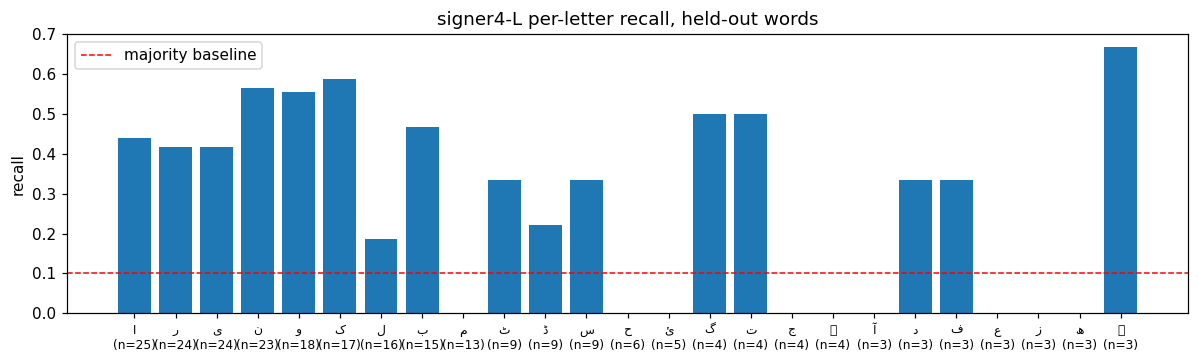

In [9]:
fig, ax = plt.subplots(figsize=(11, 3.4))
r = rep.sort_values("support", ascending=False)
ax.bar(range(len(r)), r["recall"], color="C0")
ax.set_xticks(range(len(r)), [f"{i}\n(n={int(s)})" for i, s in zip(r.index, r.support)], fontsize=8)
ax.axhline(b4, color="r", ls="--", lw=1, label="majority baseline")
ax.set_ylabel("recall"); ax.set_title("signer4-L per-letter recall, held-out words")
ax.legend(); plt.tight_layout(); plt.show()

Even here the tail is unusable: letters with 3–4 occurrences have recall estimated from a
handful of samples, so their numbers carry essentially no information. This is the structural
imbalance from `pseudo_labeling.ipynb` — a letter appearing in one word cannot have more than
five independent occurrences in the entire corpus, regardless of frame count.

## Ablation: which feature family, and does frame-level scoring mislead?

In [10]:
rows = []
for name, kw in [("normalized keypoints only", dict(use_keypoints=True, use_distances=False)),
                 ("robust d_ distances only", dict(use_keypoints=False, use_distances=True)),
                 ("both", dict(use_keypoints=True, use_distances=True))]:
    Xf, mf = occurrence_table(frames, df, **kw)
    yf = mf.letter.to_numpy(); sf = mf.signer_id.to_numpy()
    cf = (mf.signer_id + "/" + mf.video_id).to_numpy()
    a_cross, b_cross, _, _ = evaluate(Xf, yf, sf)
    k4 = sf == "signer4-L"
    a_in, b_in, _, _ = evaluate(Xf[k4], yf[k4], cf[k4])
    rows.append({"features": name,
                 "cross-signer %": 100 * a_cross, "(baseline)": 100 * b_cross,
                 "signer4-L within %": 100 * a_in, "(baseline) ": 100 * b_in})
print(pd.DataFrame(rows).round(1).to_string(index=False))

                 features  cross-signer %  (baseline)  signer4-L within %  (baseline) 
normalized keypoints only             6.3         9.1                34.4         10.0
 robust d_ distances only             6.7         9.1                30.4         10.0
                     both             6.8         9.1                36.0         10.0


In [11]:
# What frame-level scoring would have reported -- the mistake this notebook avoids.
from letter_features import build_features
held = frames[(frames.label.notna()) & (frames.label != "<TRANS>")]
mg = held.merge(df, on=["signer_id", "video_id", "frame_id"], how="left")
mg = mg[mg.hand_detected == 1].reset_index(drop=True)
Xfr = build_features(mg)
yfr = mg.label.to_numpy()

from sklearn.model_selection import cross_val_score, StratifiedKFold
naive = cross_val_score(
    RandomForestClassifier(200, random_state=0, n_jobs=-1), Xfr, yfr,
    cv=StratifiedKFold(5, shuffle=True, random_state=0), n_jobs=1).mean()
print(f"FRAME-level, random stratified split:  {100*naive:.1f}%   <-- wrong, leaks holds")
print(f"OCCURRENCE-level, grouped by signer:   {100*acc:.1f}%   <-- honest")
print(f"\ninflation factor: {naive/acc:.1f}x")

FRAME-level, random stratified split:  74.6%   <-- wrong, leaks holds
OCCURRENCE-level, grouped by signer:   6.8%   <-- honest

inflation factor: 10.9x


That gap is the entire point of the evaluation discipline. Frames inside one hold are
near-identical, so a random frame split puts near-duplicates on both sides and reports a number
several times the honest one. The inflated figure is the kind that gets published; the grouped
figure is the one that predicts behaviour on a new signer.

## Conclusions

**What works**
- SOFI Algorithm 2 segments reliably (MAE ~1.2 letters, stable leave-one-signer-out).
- Constrained alignment turns that into frame-level pseudo-labels with no count error.
- For signer4-L the labels support letter classification at 3.6x the majority baseline on
  held-out words — proof the pipeline can produce genuinely informative labels.

**What does not**
- Cross-signer letter classification from these features is at or below baseline for every
  signer and both model families.
- The same features predict signer identity at ~97 %. They encode *whose hand it is* far more
  strongly than *what shape it is in*.
- Four of five signers show no within-signer signal above their label-shuffle control either.

**The diagnosis.** 2D MediaPipe landmarks, even canonicalised for position, scale and in-plane
rotation, do not isolate handshape. PSL fingerspelling distinguishes letters largely by finger
configuration and contact, much of which projects ambiguously into 2D — and differently for
each signer's hand and camera angle. This is the *Illusion-to-Reality Gap* result reappearing
one level down: not a model that overfits a dataset, but a *feature space* that encodes
identity where it should encode shape.

**What this implies for the DRP.** The bottleneck is representation, not segmentation. Three
routes, in order of expected value:

1. **Appearance features.** Train a small CNN on the 240x350 hand crops at the segmented hold
   frames rather than on landmark geometry. The crops are already available and the segmenter
   already says which frames to use — this is the direct next experiment.
2. **Get the real annotations.** ~2,913 letter-labelled frames exist; every number here is
   limited by labels inferred rather than observed. Still the single highest-value unblock, and
   it would also settle how noisy these pseudo-labels actually are.
3. **Signer-invariant training.** Adversarial or gradient-reversal removal of signer identity,
   which the ~97 % signer accuracy suggests is both necessary and currently very achievable to
   measure.

**Do not** read the per-letter numbers for the rare letters as meaningful, and do not use
`mean_pick_depth` as a quality filter on the strength of the all-signer table — the control
above shows it is a signer4-L artifact.